# Global Temperature Change Analysis (1961–2022)
**Author:** Arush
**Dataset:** FAOSTAT Climate Change Indicators — country-level annual temperature
change (°C) relative to the 1951–1980 baseline, sourced from the FAO
(https://www.fao.org/faostat/en/#data/ET).

This notebook loads, cleans, and analyzes the dataset to answer:
1. How has the global average temperature anomaly evolved since 1961?
2. Which countries have warmed the most / least?
3. How does warming compare across decades?
4. How is warming distributed across countries today?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 10)


## 1. Load the data

In [2]:
df = pd.read_csv("data/climate_change_indicators.csv")
print("Shape:", df.shape)
df.head()


Shape: (225, 72)


   ObjectId                       Country ISO2 ISO3  \
0         1  Afghanistan, Islamic Rep. of   AF  AFG   
1         2                       Albania   AL  ALB   
2         3                       Algeria   DZ  DZA   
3         4                American Samoa   AS  ASM   
4         5      Andorra, Principality of   AD  AND   

                                           Indicator  ...  F2018  F2019  \
0  Temperature change with respect to a baseline ...  ...  1.544  0.910   
1  Temperature change with respect to a baseline ...  ...  2.028  1.675   
2  Temperature change with respect to a baseline ...  ...  1.210  1.115   
3  Temperature change with respect to a baseline ...  ...  1.189  1.539   
4  Temperature change with respect to a baseline ...  ...  1.919  1.964   

   F2020  F2021  F2022  
0  0.498  1.327  2.012  
1  1.498  1.536  1.518  
2  1.926  2.330  1.688  
3  1.430  1.268  1.256  
4  2.562  1.533  3.243  

[5 rows x 72 columns]

The raw file is in **wide format**: one row per country, one column per
year (`F1961` ... `F2022`), plus metadata columns (`Indicator`, `Unit`,
`Source`, etc). We reshape it to **long format** (`Country`, `year`,
`temp_change`) for analysis.

In [3]:
year_cols = [c for c in df.columns if c.startswith("F") and c[1:].isdigit()]

long_df = df.melt(
    id_vars=["Country", "ISO3"],
    value_vars=year_cols,
    var_name="year",
    value_name="temp_change",
)
long_df["year"] = long_df["year"].str[1:].astype(int)

print("Rows before dropping missing values:", len(long_df))
long_df = long_df.dropna(subset=["temp_change"])
print("Rows after dropping missing values:", len(long_df))
long_df.head()


Rows before dropping missing values: 13950
Rows after dropping missing values: 12460


                        Country ISO3  year  temp_change
0  Afghanistan, Islamic Rep. of  AFG  1961       -0.113
1                       Albania  ALB  1961        0.627
2                       Algeria  DZA  1961        0.164
3                American Samoa  ASM  1961        0.079
4      Andorra, Principality of  AND  1961        0.736

## 2. Global average temperature anomaly over time

1961 global average anomaly: +0.16 degC
2022 global average anomaly: +1.38 degC
Net increase: +1.22 degC


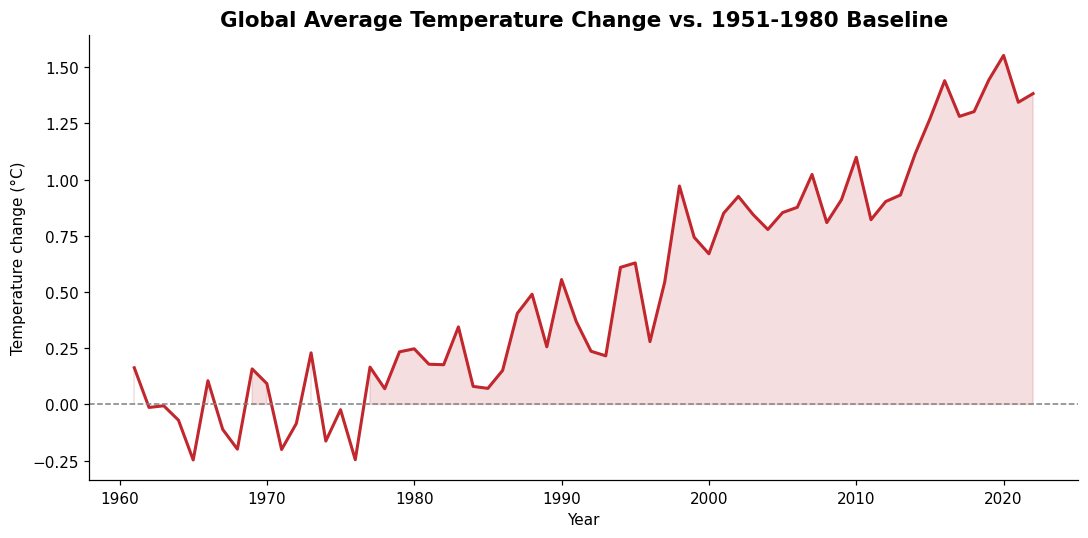

In [4]:
global_trend = long_df.groupby("year")["temp_change"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(global_trend.index, global_trend.values, color="#C1272D", linewidth=2)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.fill_between(global_trend.index, global_trend.values, 0,
                 where=(global_trend.values >= 0), color="#C1272D", alpha=0.15)
ax.set_title("Global Average Temperature Change vs. 1951-1980 Baseline", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature change (°C)")
fig.tight_layout()
fig.savefig("outputs/global_temperature_trend.png")
plt.show()

print(f"1961 global average anomaly: {global_trend.loc[1961]:+.2f} degC")
print(f"2022 global average anomaly: {global_trend.loc[2022]:+.2f} degC")
print(f"Net increase: {global_trend.loc[2022] - global_trend.loc[1961]:+.2f} degC")


The global curve trends steadily upward, especially after the 1980s —
consistent with the well-documented acceleration of global warming.

## 3. Which countries have warmed the most / least?

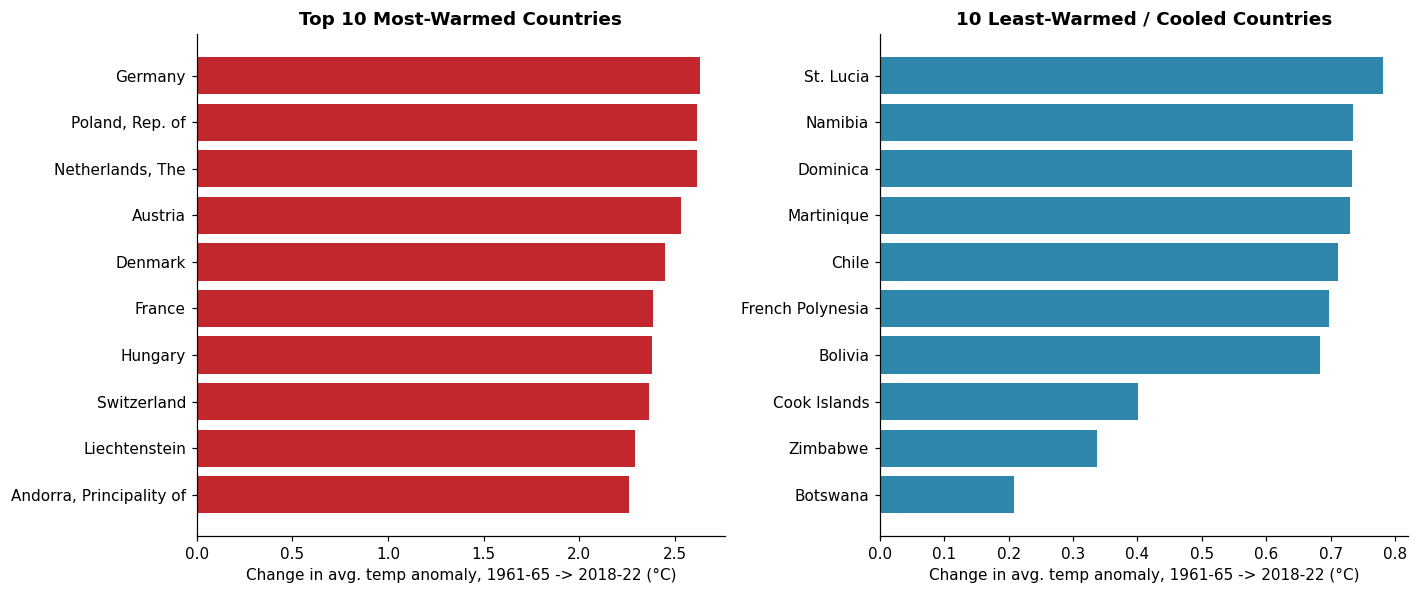

Country
Germany                     2.6296
Poland, Rep. of             2.6144
Netherlands, The            2.6136
Austria                     2.5346
Denmark                     2.4502
France                      2.3858
Hungary                     2.3810
Switzerland                 2.3650
Liechtenstein               2.2920
Andorra, Principality of    2.2614
Name: warming_delta, dtype: float64

In [5]:
# Compare the average of the first 5 years on record vs. the last 5 years,
# per country, to rank total warming.
early = long_df[long_df["year"].between(1961, 1965)].groupby("Country")["temp_change"].mean()
recent = long_df[long_df["year"].between(2018, 2022)].groupby("Country")["temp_change"].mean()

warming = (recent - early).dropna().sort_values(ascending=False)
warming.name = "warming_delta"

top10 = warming.head(10)
bottom10 = warming.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].barh(top10.index[::-1], top10.values[::-1], color="#C1272D")
axes[0].set_title("Top 10 Most-Warmed Countries", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Change in avg. temp anomaly, 1961-65 -> 2018-22 (°C)")

axes[1].barh(bottom10.index[::-1], bottom10.values[::-1], color="#2E86AB")
axes[1].set_title("10 Least-Warmed / Cooled Countries", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Change in avg. temp anomaly, 1961-65 -> 2018-22 (°C)")

fig.tight_layout()
fig.savefig("outputs/top_bottom_warming_countries.png")
plt.show()

top10


## 4. Decade-by-decade comparison

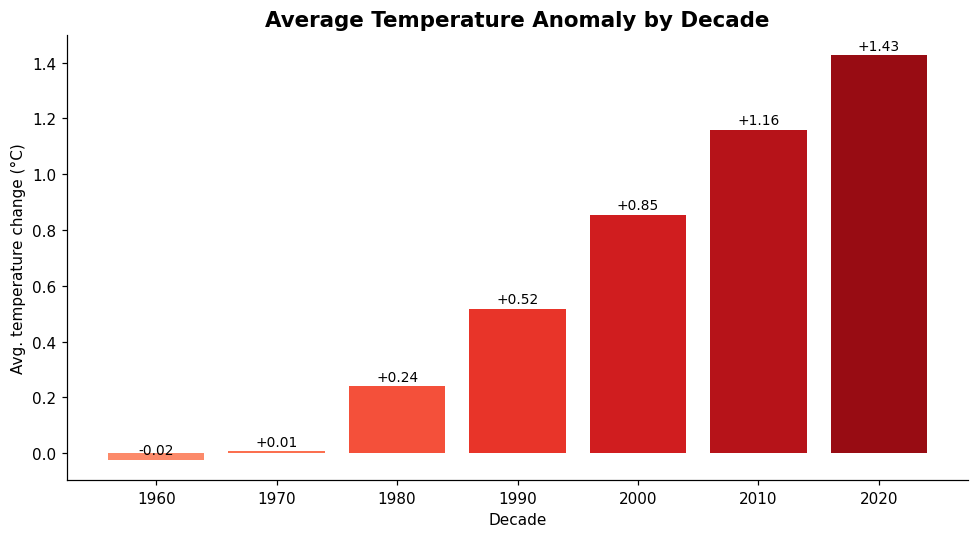

decade
1960   -0.024384
1970    0.006840
1980    0.240337
1990    0.516585
2000    0.854462
2010    1.159289
2020    1.425696
Name: temp_change, dtype: float64

In [6]:
long_df["decade"] = (long_df["year"] // 10) * 10
decade_avg = long_df.groupby("decade")["temp_change"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(decade_avg)))
ax.bar(decade_avg.index.astype(str), decade_avg.values, color=colors)
ax.set_title("Average Temperature Anomaly by Decade", fontsize=14, fontweight="bold")
ax.set_xlabel("Decade")
ax.set_ylabel("Avg. temperature change (°C)")
for i, v in enumerate(decade_avg.values):
    ax.text(i, v + 0.02, f"{v:+.2f}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig("outputs/decade_comparison.png")
plt.show()

decade_avg


## 5. Distribution of warming across all countries (latest year)

count    213.000000
mean       1.382113
std        0.669279
min       -1.305000
25%        0.878000
50%        1.315000
75%        1.918000
max        3.243000
Name: temp_change, dtype: float64


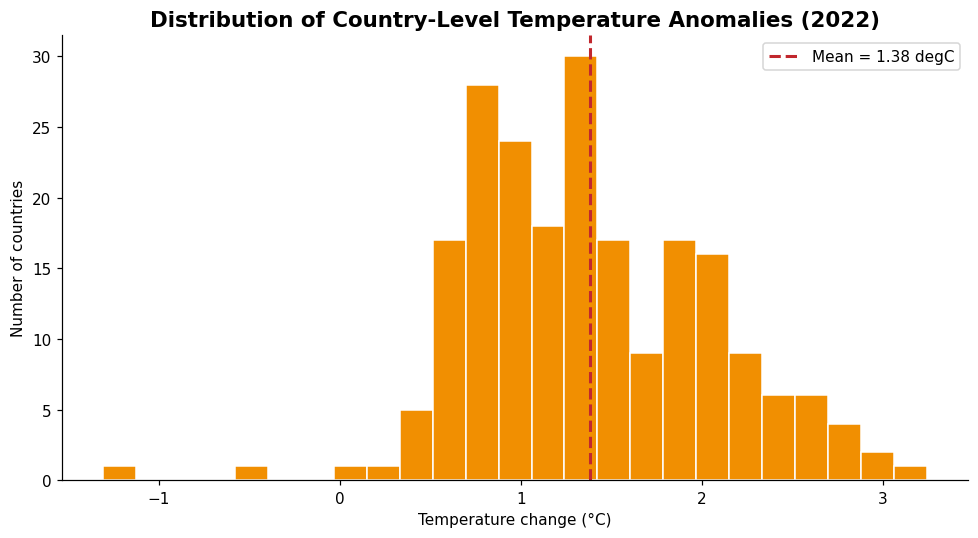

In [7]:
latest_year = long_df["year"].max()
latest = long_df[long_df["year"] == latest_year]["temp_change"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(latest, bins=25, color="#F18F01", edgecolor="white")
ax.axvline(latest.mean(), color="#C1272D", linestyle="--", linewidth=2,
           label=f"Mean = {latest.mean():.2f} degC")
ax.set_title(f"Distribution of Country-Level Temperature Anomalies ({latest_year})", fontsize=14, fontweight="bold")
ax.set_xlabel("Temperature change (°C)")
ax.set_ylabel("Number of countries")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/warming_distribution.png")
plt.show()

print(latest.describe())


## 6. Heatmap: top 15 warmest countries across decades

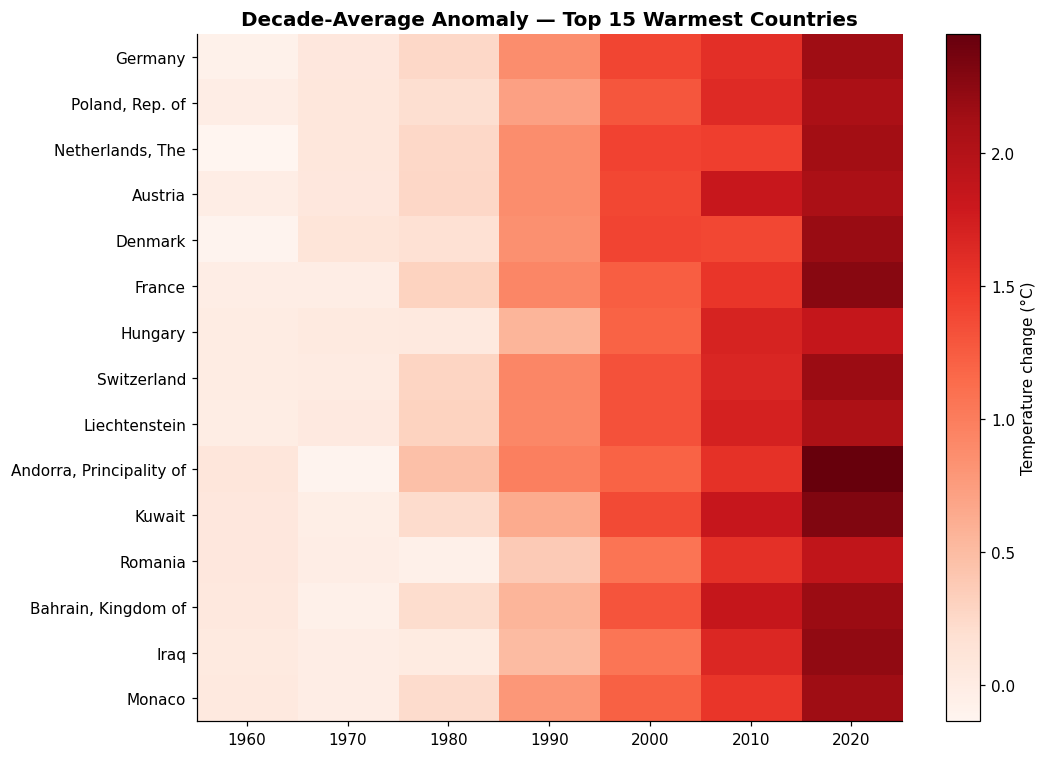

In [8]:
top15_countries = warming.head(15).index
heat_data = long_df[long_df["Country"].isin(top15_countries)].groupby(
    ["Country", "decade"]
)["temp_change"].mean().unstack("decade")
heat_data = heat_data.loc[top15_countries]  # keep ranking order

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(heat_data.values, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns.astype(str))
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index)
ax.set_title("Decade-Average Anomaly — Top 15 Warmest Countries", fontsize=13, fontweight="bold")
fig.colorbar(im, ax=ax, label="Temperature change (°C)")
fig.tight_layout()
fig.savefig("outputs/top15_heatmap.png")
plt.show()


## 7. Key insights

- **Global warming is clear and accelerating.** The global average anomaly
  rose from roughly the baseline level in the 1960s to over +1.3°C by 2022,
  with the steepest increases occurring after the 1990s.
- **Warming is uneven across countries.** Some countries (often at high
  latitudes) show anomalies well above the global average, while a small
  number of countries show little change or slight cooling over the period.
- **Every decade since the 1960s has been warmer than the last**, based on
  the decade-average comparison, reinforcing the long-term warming trend.
- **The spread across countries is wide** even within a single recent year,
  showing that "global average warming" hides substantial regional variation.

## Limitations
- The dataset reports temperature *anomalies* relative to a 1951–1980
  baseline, not absolute temperatures — appropriate for trend analysis but
  not for comparing "hottest" countries in absolute terms.
- Some countries have missing data for early years (see the row-count drop
  during cleaning), which can slightly bias country-level rankings that rely
  on the earliest years.
- Country boundaries and names in the source (e.g. dependent territories)
  are used as provided by FAOSTAT and not consolidated further.
